# NB1 — SFT-mini: Build the Lab 21 SFT checkpoint inline

**Stack:** Unsloth + LoRA r=16 + bitsandbytes 4-bit base + 1k VN Alpaca, 1 epoch.
Maps to deck §1 (why SFT alone insufficient — motivates the upcoming DPO step) +
deck §3 (DPO will need this SFT checkpoint as initial policy).

> **Mục tiêu:** tạo 1 SFT adapter "đủ tốt" để DPO có gì align lên. Đây là
> Lab 21 thu gọn — nếu bạn đã hoàn thành Lab 21 sibling repo
> ([VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA](https://github.com/VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA)),
> bạn có thể SKIP notebook này và copy adapter cũ vào `adapters/sft-mini/`.
>
> Nếu chưa, notebook này build từ đầu trong ~10 phút trên T4 (15 phút trên Colab CPU runtime — *đừng làm vậy*).

## 0. Setup

In [2]:
import os
from pathlib import Path

# Tier detection. Defaults to T4 if env not set.
COMPUTE_TIER = os.environ.get("COMPUTE_TIER", "T4").upper()
assert COMPUTE_TIER in ("T4", "BIGGPU"), f"Invalid COMPUTE_TIER: {COMPUTE_TIER}"

# Tier-specific hyperparameters
if COMPUTE_TIER == "T4":
    BASE_MODEL = "unsloth/Qwen2.5-3B-bnb-4bit"
    MAX_LEN = 512
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 8
else:  # BIGGPU
    BASE_MODEL = "unsloth/Qwen2.5-7B-bnb-4bit"
    MAX_LEN = 1024
    PER_DEVICE_BATCH = 2
    GRAD_ACCUM = 4

SFT_DATASET = os.environ.get("SFT_DATASET", "yahma/alpaca-cleaned")
SFT_SLICE = 1000
NUM_EPOCHS = 1

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ADAPTER_OUT = REPO_ROOT / "adapters" / "sft-mini"
ADAPTER_OUT.mkdir(parents=True, exist_ok=True)

print(f"COMPUTE_TIER:    {COMPUTE_TIER}")
print(f"BASE_MODEL:      {BASE_MODEL}")
print(f"SFT_DATASET:     {SFT_DATASET}  (slice: {SFT_SLICE})")
print(f"max_seq_length:  {MAX_LEN}")
print(f"effective batch: {PER_DEVICE_BATCH * GRAD_ACCUM}")
print(f"output:          {ADAPTER_OUT}")

COMPUTE_TIER:    T4
BASE_MODEL:      unsloth/Qwen2.5-3B-bnb-4bit
SFT_DATASET:     yahma/alpaca-cleaned  (slice: 1000)
max_seq_length:  512
effective batch: 8
output:          /content/adapters/sft-mini


In [9]:
import torch

assert torch.cuda.is_available(), "DPO needs a CUDA GPU. See HARDWARE-GUIDE.md."
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}  ({gpu.total_memory / 1e9:.1f} GB)")

GPU: Tesla T4  (15.6 GB)


## 1. Load base model with Unsloth

Unsloth bundles patched 4-bit kernels — that's how Qwen2.5-3B (or 7B) stays
in T4 / A100 budget. The `FastLanguageModel.from_pretrained` call returns a
4-bit quantized base; `get_peft_model` attaches the LoRA adapter on top.

In [12]:
import warnings
warnings.filterwarnings('ignore')

!pip install unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 2.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 713.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2

In [3]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_LEN,
    dtype=None,                # auto: bf16 on Ampere+, fp16 on Turing
    load_in_4bit=True,
)

# Critical for batch training — Qwen tokenizers ship without pad token.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Set tokenizer.pad_token = eos_token")

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=32,
    lora_dropout=0.0,           # Unsloth supports dropout=0 for free speed
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing="unsloth",  # 30% VRAM savings
    random_state=42,
    use_rslora=False,
    loftq_config=None,
)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Unsloth 2026.6.9 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Trainable params: 29,933,568


## 2. Load + format VN Alpaca slice

`5CD-AI/Vietnamese-alpaca-cleaned` is a 50k-row VN Alpaca translation. Lab 21
uses 1k slice for the demo run; we match that exactly so reward gap is comparable.

In [5]:
from datasets import load_dataset
from huggingface_hub import login

login()
ds = load_dataset(SFT_DATASET, split=f"train[:{SFT_SLICE}]")
print(f"Loaded {len(ds)} rows. Columns: {ds.column_names}")
print(f"\nFirst row:\n{ds[0]}")

Loaded 1000 rows. Columns: ['output', 'input', 'instruction']

First row:
{'output': '1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.\n\n2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.\n\n3. Get enough sleep: Getting enough quality sleep is crucial for physical and mental well-being. It helps to regulate mood, improve cognitive function, and supports healthy growth and immune function. Aim for 7-9 hours of sleep each night.', 'input': '', 'instruction': 'Give three tips for staying healthy.'}


In [7]:
tokenizer.chat_template = (
    "{% for message in messages %}"
        "{% if message['role'] == 'user' %}"
            "{{ '<|im_start|>user\n' + message['content'] + '<|im_end|>' }}"
        "{% elif message['role'] == 'system' %}"
            "{{ '<|im_start|>system\n' + message['content'] + '<|im_end|>' }}"
        "{% elif message['role'] == 'assistant' %}"
            "{{ '<|im_start|>assistant\n' + message['content'] + '<|im_end|>' }}"
        "{% endif %}"
    "{% endfor %}"
    "{% if add_generation_prompt %}"
        "{{ '<|im_start|>assistant\n' }}"
    "{% endif %}"
)

# Alpaca → ChatML format (Qwen2.5's native template)
def format_alpaca_to_chat(row):
    messages = []
    if row.get("instruction"):
        prompt = row["instruction"]
        if row.get("input"):
            prompt += "\n\n" + row["input"]
        messages.append({"role": "user", "content": prompt})
    if row.get("output"):
        messages.append({"role": "assistant", "content": row["output"]})
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}


ds_formatted = ds.map(format_alpaca_to_chat, remove_columns=ds.column_names)
print(f"\nSample formatted text (first 500 chars):\n{ds_formatted[0]['text'][:500]}")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


Sample formatted text (first 500 chars):
<|im_start|>user
Give three tips for staying healthy.<|im_end|><|im_start|>assistant
1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.

2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim f


## 3. Train SFT-mini

In [10]:
from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir=str(ADAPTER_OUT.parent / "sft-mini-checkpoints"),
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,
    save_strategy="no",        # Save only at the end via trainer.model.save_pretrained
    optim="adamw_8bit",
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    seed=42,
    max_length=MAX_LEN,
    dataset_text_field="text",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=sft_config,
    train_dataset=ds_formatted,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [11]:
train_result = trainer.train()
print(f"\nFinal train loss: {train_result.training_loss:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 1 | Total steps = 125
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
10,1.738157
20,1.414892
30,1.279953
40,1.305705
50,1.335511
60,1.299788
70,1.307053
80,1.248509
90,1.284198
100,1.306473



Final train loss: 1.3439


### 3a. Plot loss curve (deliverable: `02_sft_loss.png`)

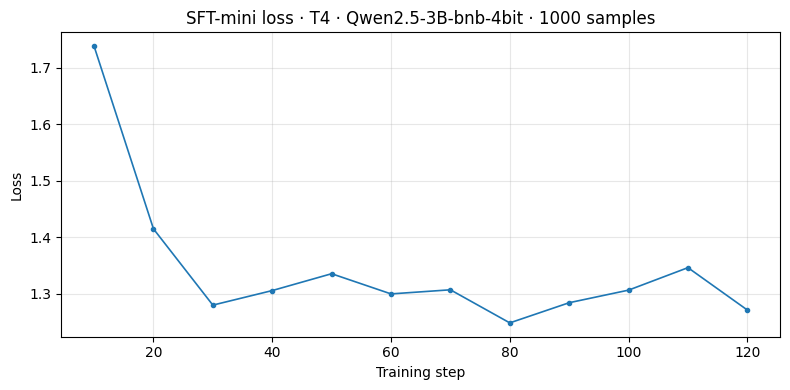

In [15]:
import matplotlib.pyplot as plt

losses = [log["loss"] for log in trainer.state.log_history if "loss" in log]
steps = [log["step"] for log in trainer.state.log_history if "loss" in log]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, losses, marker="o", markersize=3, linewidth=1.2)
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title(f"SFT-mini loss · {COMPUTE_TIER} · {BASE_MODEL.split('/')[-1]} · {SFT_SLICE} samples")
ax.grid(True, alpha=0.3)
fig.tight_layout()
screenshot_dir = REPO_ROOT / "submission" / "screenshots"
screenshot_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(screenshot_dir / "01-sft-loss.png", dpi=120)
plt.show()

## 4. Save adapter + sanity-check generation

In [13]:
trainer.model.save_pretrained(str(ADAPTER_OUT))
tokenizer.save_pretrained(str(ADAPTER_OUT))
print(f"Saved SFT adapter to {ADAPTER_OUT}")

Unsloth: Restored added_tokens_decoder metadata in /content/adapters/sft-mini/tokenizer_config.json.


Saved SFT adapter to /content/adapters/sft-mini


In [16]:
import shutil
from google.colab import files

# Zip the adapter folder
shutil.make_archive(str(ADAPTER_OUT.parent / "sft-mini"), 'zip', ADAPTER_OUT)

# Download the zipped file
files.download(str(ADAPTER_OUT.parent / "sft-mini.zip"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Sanity: generate 1 sample to confirm the adapter loaded correctly.
FastLanguageModel.for_inference(model)
prompt = "Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào."
messages = [{"role": "user", "content": prompt}]
inputs = tokenizer.apply_chat_template(
    messages, return_tensors="pt", add_generation_prompt=True
).to("cuda")
with torch.no_grad():
    out = model.generate(input_ids=inputs, max_new_tokens=200, do_sample=False)
generated = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
print(f"PROMPT: {prompt}\n")
print(f"SFT-mini response:\n{generated}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_

PROMPT: Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào.

SFT-mini response:
QuickSort is a divide-and-conquer algorithm that works by selecting a 'pivot' element from the array and partitioning the other elements into two sub-arrays, according to whether they are less than or greater than the pivot. The sub-arrays are then recursively sorted. The process continues until the sub-arrays are small enough to be sorted in constant time. The pivot element is then placed in its final position, and the process is repeated for the sub-arrays. This process continues until the entire array is sorted.퀵排序是一种分治算法，它通过选择一个“枢轴”元素从数组中，将其他元素分为两个子数组，根据它们是否小于或大于枢轴元素进行分区。然后，将子数组递归地排序。这个过程继续，直到子数组足够小，可以在常数时间内排序。然后，枢轴元素被放置在最终位置，然后对子数组进行同样的过程。这个过程继续，直到整个数组排序完成。


## 5. Vibe-coding callout

Bạn vừa tái tạo Lab 21 trong ~10 phút. Một câu hỏi để brainstorm:

> **Thật ra, bạn cần *bao nhiêu* SFT để DPO có ý nghĩa?**
>
> Thử thay `SFT_SLICE = 1000` → `100`. Re-run NB1 → NB3 với SFT yếu hơn.
> Quan sát: reward gap có còn tăng được không? Output coherent không?
>
> Đây là 1 design decision *think-hard zone* (xem VIBE-CODING.md): không có
> đáp án sẵn trong deck. Hypothesize trước, train sau, viết kết quả vào
> `submission/REFLECTION.md` § 6.

**Next:** NB2 — load + format preference data.